# Day 9: Finalizing Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

from pathlib import Path
from collections import defaultdict

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Loading Data

In [2]:
def find_project_root():
    current = Path.cwd()

    for path in [current] + list(current.parents):
        if (path / "data").exists():
            return path

    raise FileNotFoundError("Could not find project root. Make sure this notebook is inside your project folder.")


PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", DATA_PROCESSED)
print("Models folder:", MODELS_DIR)

Project root: /Users/rayhanrinzan/fifa-world-cup-predictor
Processed data folder: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed
Models folder: /Users/rayhanrinzan/fifa-world-cup-predictor/models


In [3]:
matches = pd.read_csv(DATA_PROCESSED / "matches_with_results.csv")
matchup_df = pd.read_csv(DATA_PROCESSED / "matchup_training_data.csv")

matches["date"] = pd.to_datetime(matches["date"])
matchup_df["date"] = pd.to_datetime(matchup_df["date"])

print("Raw matches:", matches.shape)
print("Matchup training data:", matchup_df.shape)

matches.head()

Raw matches: (49450, 10)
Matchup training data: (49454, 29)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,home_win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,home_win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,home_win


In [4]:
# Keep only matches with real scores
matches_played = matches.dropna(subset=["home_score", "away_score"]).copy()

# Also keep only matchup rows with real scores
matchup_played = matchup_df.dropna(subset=["team_a_goals", "team_b_goals"]).copy()

print("Played raw matches:", matches_played.shape)
print("Played matchup rows:", matchup_played.shape)

print("\nRemoved raw matches:", len(matches) - len(matches_played))
print("Removed matchup rows:", len(matchup_df) - len(matchup_played))

Played raw matches: (49378, 10)
Played matchup rows: (49382, 29)

Removed raw matches: 72
Removed matchup rows: 72


## Rebuilding Elo Ratings

In [5]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating_a, rating_b, actual_a, k=30):
    expected_a = expected_score(rating_a, rating_b)
    return rating_a + k * (actual_a - expected_a)

In [6]:
matches_played = matches_played.sort_values("date").reset_index(drop=True)

elo_ratings = defaultdict(lambda: 1500)
elo_rows = []

for _, row in matches_played.iterrows():
    home_team = row["home_team"]
    away_team = row["away_team"]

    home_score = row["home_score"]
    away_score = row["away_score"]

    home_elo_before = elo_ratings[home_team]
    away_elo_before = elo_ratings[away_team]

    if home_score > away_score:
        home_actual = 1
        away_actual = 0
    elif home_score < away_score:
        home_actual = 0
        away_actual = 1
    else:
        home_actual = 0.5
        away_actual = 0.5

    home_elo_after = update_elo(
        home_elo_before,
        away_elo_before,
        home_actual,
        k=30
    )

    away_elo_after = update_elo(
        away_elo_before,
        home_elo_before,
        away_actual,
        k=30
    )

    elo_rows.append({
        "date": row["date"],
        "home_team": home_team,
        "away_team": away_team,
        "home_score": home_score,
        "away_score": away_score,
        "home_elo_before": home_elo_before,
        "away_elo_before": away_elo_before,
        "home_elo_after": home_elo_after,
        "away_elo_after": away_elo_after
    })

    elo_ratings[home_team] = home_elo_after
    elo_ratings[away_team] = away_elo_after


elo_df = pd.DataFrame(elo_rows)

elo_df.head()

,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,1500.000000,1500.000000,1515.000000,1485.000000
2,1874-03-07,Scotland,England,2.0,1.0,1485.000000,1515.000000,1501.291995,1498.708005
3,1875-03-06,England,Scotland,2.0,2.0,1498.708005,1501.291995,1498.819563,1501.180437
4,1876-03-04,Scotland,England,3.0,0.0,1501.180437,1498.819563,1516.078511,1483.921489


In [7]:
final_elo_df = pd.DataFrame(
    list(elo_ratings.items()),
    columns=["team", "final_elo"]
).sort_values("final_elo", ascending=False)

final_elo_path = DATA_PROCESSED / "final_elo_ratings.csv"
final_elo_df.to_csv(final_elo_path, index=False)

print("Saved final Elo ratings to:", final_elo_path)

final_elo_df.head(20)

Saved final Elo ratings to: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed/final_elo_ratings.csv


,team,final_elo
40,Spain,2045.338589
7,Argentina,2044.953290
12,France,1987.831227
33,Brazil,1948.232606
49,Portugal,1946.468035
21,Germany,1943.485786
1,England,1938.966130
85,Colombia,1930.337114
17,Netherlands,1917.394646
35,Japan,1911.352154


In [8]:
home_perspective_elo = elo_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "home_elo_before",
        "away_elo_before"
    ]
].copy()

home_perspective_elo = home_perspective_elo.rename(columns={
    "home_team": "team_a",
    "away_team": "team_b",
    "home_score": "team_a_goals",
    "away_score": "team_b_goals",
    "home_elo_before": "team_a_elo_before",
    "away_elo_before": "team_b_elo_before"
})


away_perspective_elo = elo_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "home_elo_before",
        "away_elo_before"
    ]
].copy()

away_perspective_elo = away_perspective_elo.rename(columns={
    "away_team": "team_a",
    "home_team": "team_b",
    "away_score": "team_a_goals",
    "home_score": "team_b_goals",
    "away_elo_before": "team_a_elo_before",
    "home_elo_before": "team_b_elo_before"
})


elo_matchup_format = pd.concat(
    [home_perspective_elo, away_perspective_elo],
    ignore_index=True
)

elo_matchup_format.head()

,date,team_a,team_b,team_a_goals,team_b_goals,team_a_elo_before,team_b_elo_before
0,1872-11-30,Scotland,England,0.0,0.0,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,1500.000000,1500.000000
2,1874-03-07,Scotland,England,2.0,1.0,1485.000000,1515.000000
3,1875-03-06,England,Scotland,2.0,2.0,1498.708005,1501.291995
4,1876-03-04,Scotland,England,3.0,0.0,1501.180437,1498.819563


## Preventing Merge Issues

In [9]:
merge_keys = [
    "date",
    "team_a",
    "team_b",
    "team_a_goals",
    "team_b_goals"
]

matchup_for_merge = matchup_played.copy()
elo_for_merge = elo_matchup_format.copy()

matchup_for_merge["_row_id"] = np.arange(len(matchup_for_merge))
elo_for_merge["_elo_row_id"] = np.arange(len(elo_for_merge))

matchup_for_merge["_match_occurrence"] = (
    matchup_for_merge
    .sort_values("_row_id")
    .groupby(merge_keys)
    .cumcount()
)

elo_for_merge["_match_occurrence"] = (
    elo_for_merge
    .sort_values("_elo_row_id")
    .groupby(merge_keys)
    .cumcount()
)

clean_merge_keys = merge_keys + ["_match_occurrence"]

matchup_with_elo = matchup_for_merge.merge(
    elo_for_merge[
        clean_merge_keys + [
            "team_a_elo_before",
            "team_b_elo_before"
        ]
    ],
    on=clean_merge_keys,
    how="left",
    validate="one_to_one"
)

matchup_with_elo = matchup_with_elo.drop(columns=["_row_id"])

print("Rows before merge:", len(matchup_played))
print("Rows after merge:", len(matchup_with_elo))
print("Missing Elo rows:", matchup_with_elo["team_a_elo_before"].isna().sum())

Rows before merge: 49382
Rows after merge: 49382
Missing Elo rows: 4


## Saving Clean Dataset

In [10]:
matchup_with_elo["elo_diff"] = (
    matchup_with_elo["team_a_elo_before"]
    - matchup_with_elo["team_b_elo_before"]
)

clean_elo_path = DATA_PROCESSED / "matchup_training_data_with_clean_elo.csv"

matchup_with_elo.to_csv(clean_elo_path, index=False)

print("Saved clean Elo matchup dataset to:", clean_elo_path)

matchup_with_elo[
    [
        "date",
        "team_a",
        "team_b",
        "team_a_goals",
        "team_b_goals",
        "team_a_elo_before",
        "team_b_elo_before",
        "elo_diff",
        "target"
    ]
].head()

Saved clean Elo matchup dataset to: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed/matchup_training_data_with_clean_elo.csv


,date,team_a,team_b,team_a_goals,team_b_goals,team_a_elo_before,team_b_elo_before,elo_diff,target
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,1500.000000,1500.000000,0.000000,draw
1,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,1485.000000,1500.000000,-15.000000,win
2,2014-06-01,Abkhazia,Occitania,1.0,1.0,1500.647200,1604.858553,-104.211353,draw
3,2014-06-04,Abkhazia,South Ossetia,0.0,0.0,1520.262723,1488.777536,31.485187,draw
4,2014-06-07,Abkhazia,Occitania,0.0,1.0,1523.686205,1606.255290,-82.569085,loss


## Creating Train/Test Split

In [17]:
df = matchup_with_elo.copy()

features_with_elo = [
    "last_5_points_per_match_diff",
    "last_5_goals_for_per_match_diff",
    "last_5_goals_against_per_match_diff",
    "last_5_goal_difference_per_match_diff",
    "last_5_win_diff",
    "last_5_draw_diff",
    "last_5_loss_diff",
    "elo_diff"
]

target = "target"

# Check missing values before fixing
print("Missing values before cleanup:")
print(df[features_with_elo].isna().sum())

# If Elo is missing, that likely means the merge failed for those rows.
# Since Elo is important, drop rows where elo_diff is missing.
rows_before = len(df)
df = df.dropna(subset=["elo_diff"]).copy()
rows_after = len(df)

print("\nRows dropped because of missing Elo:", rows_before - rows_after)

# For missing recent-form differences, fill with 0.
# Interpretation: no known recent-form advantage for either team.
recent_form_diff_cols = [
    "last_5_points_per_match_diff",
    "last_5_goals_for_per_match_diff",
    "last_5_goals_against_per_match_diff",
    "last_5_goal_difference_per_match_diff",
    "last_5_win_diff",
    "last_5_draw_diff",
    "last_5_loss_diff"
]

df[recent_form_diff_cols] = df[recent_form_diff_cols].fillna(0)

# Final check
print("\nMissing values after cleanup:")
print(df[features_with_elo].isna().sum())

assert df[features_with_elo].isna().sum().sum() == 0, "There are still NaN values in the features."

train_df = df[df["date"] < "2018-01-01"].copy()
test_df = df[df["date"] >= "2018-01-01"].copy()

X_train = train_df[features_with_elo]
y_train = train_df[target]

X_test = test_df[features_with_elo]
y_test = test_df[target]

print("\nTrain size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Missing values before cleanup:
last_5_points_per_match_diff             0
last_5_goals_for_per_match_diff          0
last_5_goals_against_per_match_diff      0
last_5_goal_difference_per_match_diff    0
last_5_win_diff                          0
last_5_draw_diff                         0
last_5_loss_diff                         0
elo_diff                                 4
dtype: int64

Rows dropped because of missing Elo: 4

Missing values after cleanup:
last_5_points_per_match_diff             0
last_5_goals_for_per_match_diff          0
last_5_goals_against_per_match_diff      0
last_5_goal_difference_per_match_diff    0
last_5_win_diff                          0
last_5_draw_diff                         0
last_5_loss_diff                         0
elo_diff                                 0
dtype: int64

Train size: 41297
Test size: 8081

Train distribution:
target
win     20339
loss    11594
draw     9364
Name: count, dtype: int64

Test distribution:
target
win     3860
loss    2359


## Defining Models

In [18]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

final_candidate_models = {
    "gradient_boosting_balanced_clean_elo": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "hist_gradient_boosting_balanced_clean_elo": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ),

    "logistic_balanced_clean_elo": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

## Training and Evaluating Models

In [19]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, sample_weights=None):
    if sample_weights is not None and "logistic" not in name:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    pred_counts = pd.Series(y_pred).value_counts()

    result = {
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "win_f1": report["win"]["f1-score"],
        "draw_f1": report["draw"]["f1-score"],
        "loss_f1": report["loss"]["f1-score"],
        "predicted_wins": pred_counts.get("win", 0),
        "predicted_draws": pred_counts.get("draw", 0),
        "predicted_losses": pred_counts.get("loss", 0)
    }

    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nPrediction counts:")
    print(pred_counts)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=["win", "draw", "loss"]))

    return result, y_pred

## Model Comparison

In [20]:
final_results = []
final_predictions = {}
trained_models = {}

for name, model in final_candidate_models.items():
    result, y_pred = evaluate_model(
        name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        sample_weights=sample_weights
    )

    final_results.append(result)
    final_predictions[name] = y_pred
    trained_models[name] = model

gradient_boosting_balanced_clean_elo
Accuracy: 0.568865239450563
Macro F1: 0.5278087352947648
Weighted F1: 0.5709447686699852

Prediction counts:
win     3714
loss    2437
draw    1930
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.30      0.31      0.31      1862
        loss       0.58      0.60      0.59      2359
         win       0.70      0.67      0.69      3860

    accuracy                           0.57      8081
   macro avg       0.53      0.53      0.53      8081
weighted avg       0.57      0.57      0.57      8081


Confusion matrix:
[[2604  793  463]
 [ 709  586  567]
 [ 401  551 1407]]
hist_gradient_boosting_balanced_clean_elo
Accuracy: 0.5722064100977602
Macro F1: 0.527718478544782
Weighted F1: 0.5721993567619214

Prediction counts:
win     3753
loss    2506
draw    1822
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw   

In [21]:
final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by=["macro_f1", "draw_f1", "accuracy"],
    ascending=False
)

final_results_df

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
0,gradient_boosting_balanced_clean_elo,0.568865,0.527809,0.570945,0.687616,0.309072,0.586739,3714,1930,2437
1,hist_gradient_boosting_balanced_clean_elo,0.572206,0.527718,0.572199,0.692762,0.302932,0.587461,3753,1822,2506
2,logistic_balanced_clean_elo,0.579631,0.526673,0.573941,0.699590,0.280347,0.600082,3936,1598,2547


In [22]:
best_model_name = final_results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best current model:", best_model_name)

final_results_df.iloc[0]

Best current model: gradient_boosting_balanced_clean_elo


model               gradient_boosting_balanced_clean_elo
accuracy                                        0.568865
macro_f1                                        0.527809
weighted_f1                                     0.570945
win_f1                                          0.687616
draw_f1                                         0.309072
loss_f1                                         0.586739
predicted_wins                                      3714
predicted_draws                                     1930
predicted_losses                                    2437
Name: 0, dtype: object

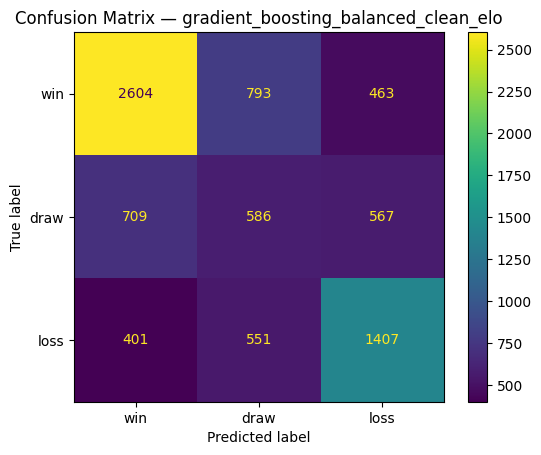

In [23]:
best_y_pred = final_predictions[best_model_name]

labels = ["win", "draw", "loss"]

cm = confusion_matrix(y_test, best_y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## Saving Best Model + Metadata

In [24]:
model_path = MODELS_DIR / "current_best_model_with_elo.pkl"
metadata_path = MODELS_DIR / "current_best_model_with_elo_metadata.json"

joblib.dump(best_model, model_path)

best_metrics = final_results_df.iloc[0].to_dict()

metadata = {
    "model_name": best_model_name,
    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
    "training_data": str(clean_elo_path.relative_to(PROJECT_ROOT)),
    "features": features_with_elo,
    "target": target,
    "train_cutoff": "2018-01-01",
    "class_labels": list(best_model.classes_) if hasattr(best_model, "classes_") else None,
    "metrics": {
        key: float(value) if isinstance(value, (np.float64, np.float32)) else int(value) if isinstance(value, (np.int64, np.int32)) else value
        for key, value in best_metrics.items()
    }
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved model to:", model_path)
print("Saved metadata to:", metadata_path)

Saved model to: /Users/rayhanrinzan/fifa-world-cup-predictor/models/current_best_model_with_elo.pkl
Saved metadata to: /Users/rayhanrinzan/fifa-world-cup-predictor/models/current_best_model_with_elo_metadata.json


In [25]:
team_matches = pd.read_csv(DATA_PROCESSED / "team_matches.csv")
team_matches["date"] = pd.to_datetime(team_matches["date"])

team_matches_played = team_matches.dropna(
    subset=["goals_for", "goals_against"]
).copy()

team_matches_played = team_matches_played.sort_values(["team", "date"])

team_matches_played.head()

,date,team,opponent,goals_for,goals_against,tournament,city,country,neutral,is_home,result,points,goal_difference
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,Friendly,Sukhumi,Georgia,False,True,draw,1,0.0
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,Friendly,Stepanakert,Azerbaijan,False,False,loss,0,-3.0
2,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,Friendly,Sukhumi,Georgia,False,True,win,3,3.0
3,2014-06-01,Abkhazia,Occitania,1.0,1.0,CONIFA World Football Cup,Östersund,Sweden,True,True,draw,1,0.0
4,2014-06-02,Abkhazia,Sápmi,2.0,1.0,CONIFA World Football Cup,Östersund,Sweden,False,False,win,3,1.0


## Building Helper for Current Team Form

In [39]:
def get_current_team_form(team_name, team_matches_played, n=5):
    team_history = (
        team_matches_played[team_matches_played["team"] == team_name]
        .sort_values("date")
        .tail(n)
    )

    matches_used = len(team_history)

    if matches_used == 0:
        return {
            "last_5_points_per_match": 0,
            "last_5_goals_for_per_match": 0,
            "last_5_goals_against_per_match": 0,
            "last_5_goal_difference_per_match": 0,
            "last_5_win": 0,
            "last_5_draw": 0,
            "last_5_loss": 0
        }

    return {
        "last_5_points_per_match": team_history["points"].sum() / matches_used,
        "last_5_goals_for_per_match": team_history["goals_for"].sum() / matches_used,
        "last_5_goals_against_per_match": team_history["goals_against"].sum() / matches_used,
        "last_5_goal_difference_per_match": team_history["goal_difference"].sum() / matches_used,
        "last_5_win": (team_history["result"] == "win").sum(),
        "last_5_draw": (team_history["result"] == "draw").sum(),
        "last_5_loss": (team_history["result"] == "loss").sum()
    }

## Building Prediction Function

In [27]:
final_elo_map = dict(zip(final_elo_df["team"], final_elo_df["final_elo"]))

form_features = [
    "last_5_points_per_match",
    "last_5_goals_for_per_match",
    "last_5_goals_against_per_match",
    "last_5_goal_difference_per_match",
    "last_5_win",
    "last_5_draw",
    "last_5_loss"
]


def build_match_features(team_a, team_b):
    team_a_form = get_current_team_form(team_a, team_matches_played)
    team_b_form = get_current_team_form(team_b, team_matches_played)

    row = {}

    for feature in form_features:
        row[f"{feature}_diff"] = team_a_form[feature] - team_b_form[feature]

    team_a_elo = final_elo_map.get(team_a, 1500)
    team_b_elo = final_elo_map.get(team_b, 1500)

    row["elo_diff"] = team_a_elo - team_b_elo

    return pd.DataFrame([row])[features_with_elo]


def predict_match(team_a, team_b, model=best_model):
    X_match = build_match_features(team_a, team_b)

    predicted_label = model.predict(X_match)[0]
    probabilities = model.predict_proba(X_match)[0]

    probability_map = dict(zip(model.classes_, probabilities))

    team_a_win_prob = probability_map.get("win", 0)
    draw_prob = probability_map.get("draw", 0)
    team_b_win_prob = probability_map.get("loss", 0)

    result = pd.DataFrame([
        {
            "team_a": team_a,
            "team_b": team_b,
            "predicted_outcome_from_team_a_perspective": predicted_label,
            "team_a_win_probability": team_a_win_prob,
            "draw_probability": draw_prob,
            "team_b_win_probability": team_b_win_prob,
            "team_a_advancement_probability_simple": team_a_win_prob + 0.5 * draw_prob,
            "team_b_advancement_probability_simple": team_b_win_prob + 0.5 * draw_prob
        }
    ])

    return result

## A Few Examples

In [31]:
predict_match("Portugal", "Croatia")

,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability_simple,team_b_advancement_probability_simple
0,Portugal,Croatia,win,0.489178,0.309648,0.201174,0.644002,0.355998


In [32]:
predict_match("Portugal", "Spain")

,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability_simple,team_b_advancement_probability_simple
0,Portugal,Spain,draw,0.227805,0.414952,0.357242,0.435281,0.564719


In [33]:
predict_match("Brazil", "Norway")

,team_a,team_b,predicted_outcome_from_team_a_perspective,team_a_win_probability,draw_probability,team_b_win_probability,team_a_advancement_probability_simple,team_b_advancement_probability_simple
0,Brazil,Norway,win,0.447419,0.370414,0.182167,0.632626,0.367374


## Current Model Decision

After cleaning the Elo dataset and removing unplayed matches, we retrained three final candidate models:

- Gradient Boosting with balanced sample weights
- HistGradientBoosting with balanced sample weights
- Balanced Logistic Regression

The selected current model is the one with the strongest combination of macro F1, draw F1, and accuracy. This matters because the final tournament simulator will need usable probabilities, not just the highest raw accuracy.

The saved model can now be loaded from:

`models/current_best_model_with_elo.pkl`

The next project step is to start building knockout-stage simulation logic using the model's win/draw/loss probabilities.